In [101]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'

# CMS Responses

In [70]:
df_CMS = pd.read_stata('../Data/drive-download-20231006T131216Z-001/Files/CMS Responses.dta')
df_CMS.head()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A01_Name_hhd_member,A02_Sex,A03_Age,...,Male_Shovel_Value,Women_Shovel_Value,Total_Production_Asset_Value,Male__Production_Value,Women__Production_Value,HouseHold_AnimalUnits,Male_Owned_Livestock,Female_Owned_Livestock,Land_Operated_Cassava_Proportion,Land_Owned_Cassava_Proportion
0,1.0,11.0,112.0,1121.0,11211.0,112111.0,1.0,MOHAMMED ALIYU,Male,47.0,...,600.0,0.0,16800.0,9150.0,7650.0,0.68,0.64,0.04,0.600000,0.600000
1,1.0,11.0,112.0,1121.0,11211.0,112112.0,1.0,H. R. H U. O Lapinni,Male,78.0,...,1200.0,0.0,21200.0,21200.0,0.0,1.38,1.10,0.28,0.090909,0.090909
2,1.0,11.0,112.0,1121.0,11211.0,112113.0,1.0,Abdurrahman Amed,Male,45.0,...,0.0,0.0,3650.0,1450.0,2200.0,0.70,0.00,0.70,0.333333,0.333333
3,1.0,11.0,112.0,1121.0,11211.0,112114.0,1.0,Mrs. Mulikatu Iyabo Ibrahim,Female,42.0,...,0.0,0.0,13200.0,3470.0,9730.0,0.34,0.12,0.22,0.203822,0.203822
4,1.0,11.0,112.0,1121.0,11211.0,112115.0,1.0,Alh. Muhammed Elega,Male,48.0,...,0.0,0.0,32896.0,29668.0,3228.0,1.10,0.70,0.40,0.181818,0.181818


# DNA Fingerprinting

In [71]:
# https://data.iita.org/dataset/the-cassava-monitoring-survey-cms-in-nigeria-household-and-plot-level-data
df_DNA = pd.read_csv("../Data/CMS-raw/dna.csv")
houseIDs = df_CMS['HouseID'].value_counts().keys()
df_DNA = df_DNA[df_DNA['HouseID'].isin(houseIDs)].groupby('HouseID', as_index=False).agg(
    {'StateID': 'min', 'adoption': ['sum', 'min']})
df_DNA.columns = ['HouseID', 'ZoneID', 'Total ICV - DNA', 'Y/N ICV - DNA']
df_DNA['ZoneID'] = (df_DNA['ZoneID']/10).astype(int)#.tail()
df_DNA.head()

,HouseID,ZoneID,Total ICV - DNA,Y/N ICV - DNA
0,112111,1,1,1
1,112112,1,1,1
2,112113,1,3,1
3,112114,1,0,0
4,112115,1,0,0


# Gender and DNA fingerprinting HHhead
**Merge:** CMS Responses and  DNA fingerprinting + A06_Relatn_hhd == Household head

In [100]:
df_CMS_HH  = df_CMS[df_CMS['A06_Relatn_hhd'] == 'Household head']
df_CMS_HH  = df_CMS_HH.rename(columns={'Household_ICV': 'Total ICV - Survey', 'planted': 'Y/N ICV - Survey',})
df_CMS_HH_DNA = pd.merge(df_DNA, df_CMS_HH[['HouseID', 'A02_Sex', 'Total ICV - Survey', 'Y/N ICV - Survey']], on='HouseID')
print('CMS + DNA dimensions', df_CMS_HH_DNA.shape)
print('Percentaje', df_CMS_HH_DNA['A02_Sex'].value_counts(normalize=True))
df_CMS_HH_DNA.head()

CMS + DNA dimensions (2115, 7)
Percentaje A02_Sex
Male      0.877899
Female    0.122101
Name: proportion, dtype: float64


,HouseID,ZoneID,Total ICV - DNA,Y/N ICV - DNA,A02_Sex,Total ICV - Survey,Y/N ICV - Survey
0,112111,1,1,1,Male,1.0,0.0
1,112112,1,1,1,Male,0.0,0.0
2,112113,1,3,1,Male,3.0,1.0
3,112114,1,0,0,Female,0.0,0.0
4,112115,1,0,0,Male,0.0,0.0


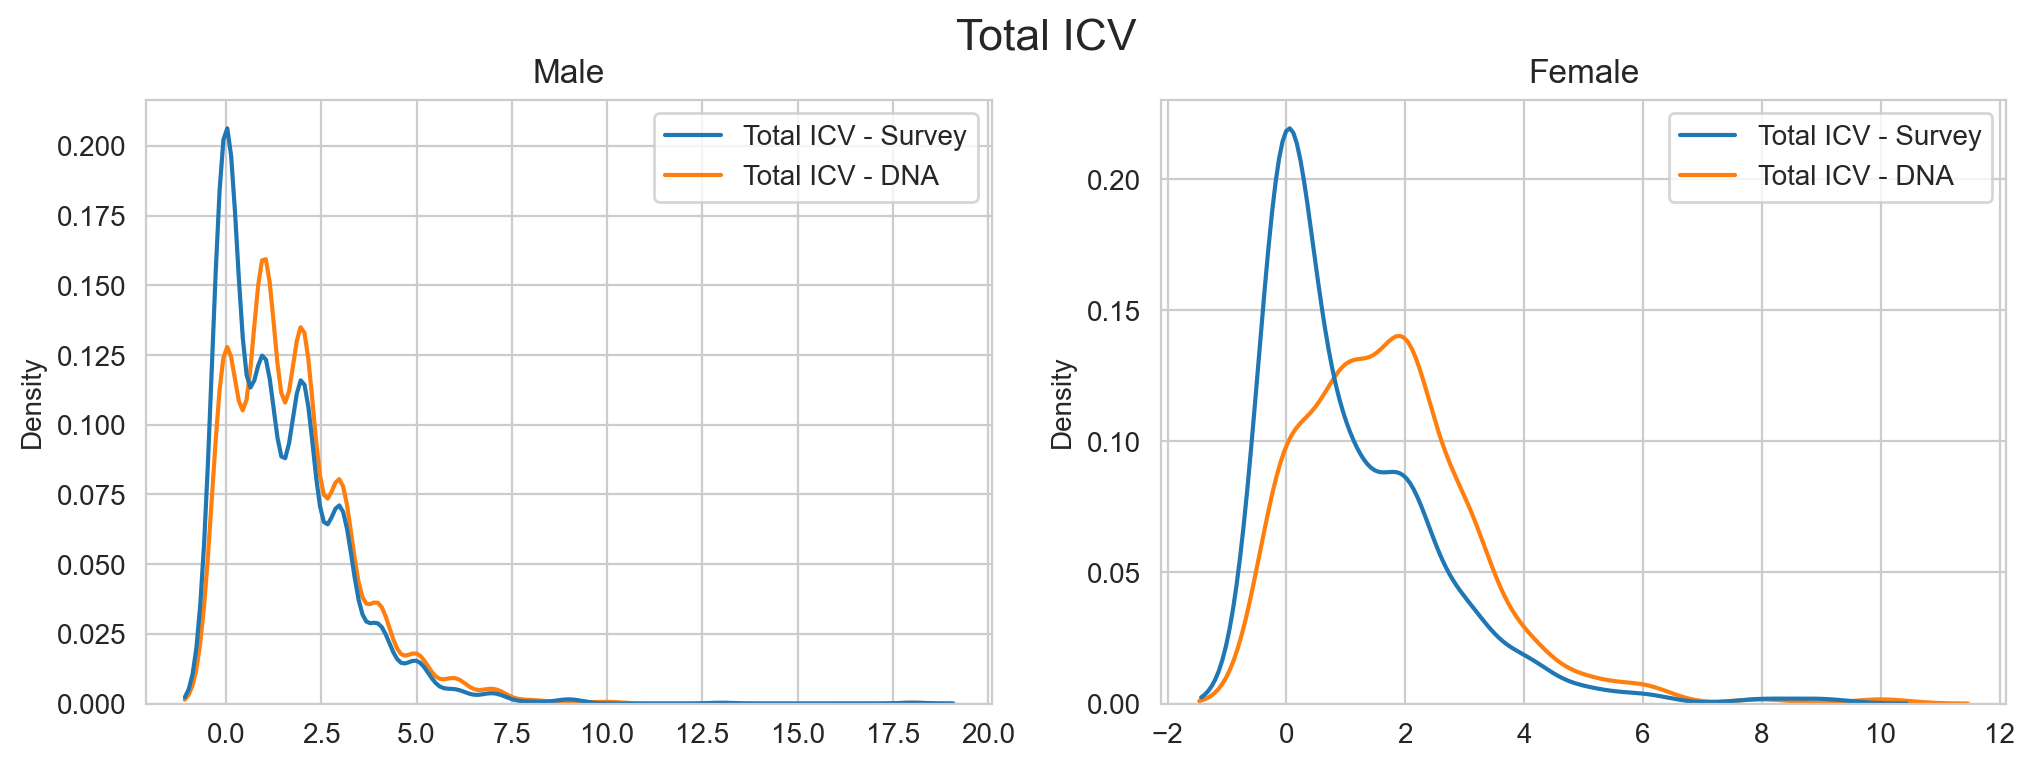

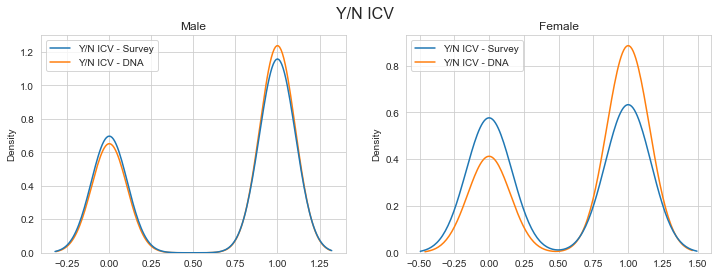

In [103]:
fig1, ax1 = plt.subplots(1, 2, figsize=(12,4), dpi=200)
sns.kdeplot(ax = ax1[0], data=df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male'][['Total ICV - Survey', 'Total ICV - DNA']])
sns.kdeplot(ax = ax1[1], data=df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female'][['Total ICV - Survey', 'Total ICV - DNA']])

fig2, ax2 = plt.subplots(1, 2, figsize=(12,4))
sns.kdeplot(ax = ax2[0], data=df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Male'][['Y/N ICV - Survey', 'Y/N ICV - DNA']])
sns.kdeplot(ax = ax2[1], data=df_CMS_HH_DNA[df_CMS_HH_DNA['A02_Sex'] == 'Female'][['Y/N ICV - Survey', 'Y/N ICV - DNA']])


ax1[0].set_title('Male')
ax2[0].set_title('Male')

ax1[1].set_title('Female')
ax2[1].set_title('Female')

fig1.suptitle('Total ICV', fontsize=16)
fig2.suptitle('Y/N ICV', fontsize=16)
fig1.savefig("../Output/TotalICV_CMS_DNA.png", dpi=200)
fig2.savefig("../Output/YNICV_CMS_DNA.png", dpi=200)

# Cassava monitoring (HH head name & GIS)

In [56]:
df_Monitoring = pd.read_stata(path_raw + 'Cassava_monitoring_All regions.dta')  
df_Monitoring# .head()#keys()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Longitude,Latitude,Altitude,Hhead_name,Resp_name,Relatnsh_hhead,Mobile_no,Interviewer_name,Supervisor_name,Date_checked,Start_time,J13_GPS_UnitID,K02_lastword,Endtime
0,1.0,11.0,1110.0,11101.0,111011.0,1110111.0,6.84741,7.69744,215.0,Winifred Waniko,Winifred Waniko,Household head,8.081387e+09,A. Elisha Hyelni Mshelia,Iliya Musa,,01/09/2015 16:34:29,4.0,"The interview was success, their was not good ...",01/09/2015 17:33:28
1,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,6.84673,7.70044,163.0,Festus Mawo Bagi,Festus Mawo Bagi,Household Head,9.096290e+09,Abdullahi Audu,Dr Adetunji,,01/09/2015 16:48:16,5.0,The farmer cooperates and response to the all ...,01/09/2015 21:29:00
2,1.0,11.0,1110.0,11101.0,111011.0,1110113.0,6.84686,7.69953,167.0,Mathias Shaka,Mathias Shaka,Household head,8.129250e+09,Ojo.S.Olusayo,Dr Tunji,,01/09/2015 16:08:17,3.0,There is no cassava processing machine in our ...,01/09/2015 21:35:35
3,1.0,11.0,1110.0,11101.0,111011.0,1110114.0,6.50810,7.42020,189.0,Peter Agam,Peter Agam,Household head,9.099637e+09,Ibrahim Ismail Akinropo,Dr. Adetunji Olanrewaju,,01/09/2015 15:57:42,2.0,The interview was successfully carrieout with ...,01/09/2015 18:32:59
4,1.0,11.0,1110.0,11101.0,111011.0,1110115.0,6.50824,7.41861,185.0,AwomElisha,Awom Elisha,Head,8.092252e+09,Yusuf Kabir,Dr. Olanrewaju,,01/09/2015 17:34:00,11.0,The interview was successful.,01/09/2015 20:34:57
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2482,4.0,43.0,4316.0,43162.0,431622.0,4316224.0,5.81578,5.41990,17.0,Robinson Okoro,Robinson Okoro,Household head,8.059059e+09,Uchenna Christopher,Mark Tokula,,25/09/2015 08:42:56,0.0,The farmer needs soft loan to help him in cass...,25/09/2015 09:12:22
2483,4.0,43.0,4316.0,43162.0,431622.0,4316221.0,5.81605,5.41976,74.0,Okoro Happy,Okoro Happy,Household head,8.152748e+09,Okonkwo Innocent,Mark Tokula,,25/09/2015 05:42:55,45.0,Oil spilage has a problem of low fertility of ...,25/09/2015 06:18:09
2484,4.0,43.0,4316.0,43162.0,431622.0,4316222.0,5.81635,5.41900,0.0,Justina Edeuchmurhe,Justina Edeuchmurhe,Household head,8.110033e+09,Ukeje Blessing,Mark Tokula,,25/09/2015 06:20:53,0.0,I need cassava stems and financial support for...,25/09/2015 07:20:56
2485,4.0,43.0,4316.0,43162.0,431622.0,4316223.0,5.81457,5.42092,12.0,Adu Irikevwie,Adu Irikevwie,Household Head,8.103022e+09,Olaniyi Abiodun,Mark Tokula,,24/09/2015 10:24:24,47.0,I need agro-allied chemical for weed control f...,24/09/2015 11:24:09


# Household composition

In [57]:
path_raw =  '../Data/drive-download-20231006T131216Z-001/Files/Data Cleaning - Individual Files/Original Files - Not Cleaned/CMS (entire database)/Files/'
df_HHcomposition = pd.read_stata(path_raw + 'Household_composition_All regions.dta')  
df_HHcomposition# .head(40)# .keys()

,ZoneID,StateID,LgaID,LocalityID,EnumerationID,HouseID,Individual_family_code,A01_Name_hhd_member,A02_Sex,A03_Age,A03_2_AGECHECK,A04_Marital_status,A05_Edu,A06_Relatn_hhd,A07_1_Main_occupatn,A07_1b_S_OCCUPATION,A07_2_Secondary_occupation,A08_fam_lab_contributn,A08_2_PROPORTIONCHECK
0,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,2.0,Cathrina Bagi,Female,55.0,Yes,Other specify,12.0,Spouse,Farming(crop+livestock),No,NaN,100%,Yes
1,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,3.0,Naedogbo Bagi,Female,50.0,Yes,Other specify,12.0,Spouse,Farming(crop+livestock),No,NaN,100%,Yes
2,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,4.0,Titus Bagi,Male,21.0,Yes,married living with spouse/s,14.0,Son/Daughter,Salaried employment,Yes,Farming(crop+livestock),50%,Yes
3,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,5.0,Sunday Bagi,Male,38.0,Yes,married living with spouse/s,16.0,Son/Daughter,Salaried employment,Yes,Farming(crop+livestock),50%,Yes
4,1.0,11.0,1110.0,11101.0,111011.0,1110112.0,6.0,Timothy Bagi,Male,50.0,Yes,married living with spouse/s,15.0,Son/Daughter,Self employed off farm,Yes,Farming(crop+livestock),50%,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11149,4.0,43.0,4316.0,43162.0,431622.0,4316224.0,5.0,Festus Okoro,Male,20.0,Yes,Never married,12.0,Spouse,Farming(crop+livestock),No,NaN,100%,Yes
11150,4.0,43.0,4316.0,43162.0,431622.0,4316224.0,3.0,Chukwu Okoro,Male,13.0,Yes,Never married,6.0,Son/Daughter,School/college child,No,NaN,10%,Yes
11151,4.0,43.0,4316.0,43162.0,431622.0,4316224.0,1.0,Robinson Okoro,Male,60.0,Yes,married living with spouse/s,6.0,Household head,Farming(crop+livestock),No,NaN,100%,Yes
11152,4.0,43.0,4316.0,43162.0,431622.0,4316224.0,2.0,Victoria Okoro,Female,35.0,Yes,married living with spouse/s,6.0,Spouse,Farming(crop+livestock),No,NaN,100%,Yes
